# OpenCV

In [1]:
!pip uninstall opencv-python -y

# Downgrade OpenCV a bit since some none-free features are not available
!pip install opencv-contrib-python==3.4.16.59 --force-reinstall

Found existing installation: opencv-python 4.8.0.76
Uninstalling opencv-python-4.8.0.76:
  Successfully uninstalled opencv-python-4.8.0.76
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 MB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.8.0.76
    Uninstalling opencv-contrib-python-4.8.0.76:
      Successfully uninstalled opencv-contrib-python-4.8.0.76
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.0.9 requires opencv-python>=3.4.8.29, which is not installed.
imgaug 0.4.0 requires opencv-python, which is not installed.


# Extract Data

In [1]:
from google.colab import drive
import zipfile as zf

drive.mount('/content/drive/')

files = zf.ZipFile("/content/drive/MyDrive/ML/dataset-resized.zip", 'r')
files.extractall()
files.close()

Mounted at /content/drive/


# File Organizing
Splits indices for a folder into train and test indices with random sampling

In [2]:
import random
import shutil
import os

## Input: folder path
## Output: train and test indices
def split_indices(folder, seed1, seed2):
    n = len(os.listdir(folder))
    full_set = list(range(1, n + 1))

    ## Train indices
    random.seed(seed1)
    train = random.sample(list(range(1, n + 1)), int(.85 * n))

    ## Separate remaining into test
    test = list(set(full_set) - set(train))

    return(train, test)

## Gets file names for a particular type of trash, given indices
## Input: waste category and indices
## Output: file names
def get_names(waste_type, indices):
    file_names = [waste_type + str(i) + ".jpg" for i in indices]
    return(file_names)

## Moves group of source files to another folder
## Input: list of source files and destination folder
## No output
def move_files(source_files, destination_folder):
    for file in source_files:
        shutil.move(file, destination_folder)

In [3]:
## Paths will be train/cardboard, train/glass, etc...
subsets = ['train', 'test']
waste_types = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

## Create destination folders for data subset and waste type
for subset in subsets:
    for waste_type in waste_types:
        folder = os.path.join('dataset', subset, waste_type)
        if not os.path.exists(folder):
            os.makedirs(folder)

## Move files to destination folders for each waste type
for waste_type in waste_types:
    source_folder = os.path.join('dataset-resized', waste_type)
    train_ind, test_ind = split_indices(source_folder, 1, 1)

    ## Move source files to train
    train_names = get_names(waste_type, train_ind)
    train_source_files = [os.path.join(source_folder, name) for name in train_names]
    train_dest = "dataset/train/" + waste_type
    move_files(train_source_files, train_dest)

    ## Move source files to test
    test_names = get_names(waste_type, test_ind)
    test_source_files = [os.path.join(source_folder, name) for name in test_names]
    test_dest = "dataset/test/" + waste_type
    move_files(test_source_files, test_dest)

#Training

In [4]:
# Get the training classes names and store them in a list
# Use folder names for class names
train_path = './dataset/train'
training_names = os.listdir(train_path)

# Get path to all images and save them in a list image_paths and the corresponding label in image_paths
image_paths = []
image_classes = []
class_id = 0

# To list all file names in a directory
def imglist(path):
    return [os.path.join(path, f) for f in os.listdir(path)]

# Fill the placeholder empty lists with image path, classes, and add class ID number
for training_name in training_names:
    dir = os.path.join(train_path, training_name)
    class_path = imglist(dir)
    image_paths += class_path
    image_classes += [class_id] * len(class_path)
    class_id += 1

Feature Extraction using Scale Invariant Feature Transform (SIFT) Algorithm

In [5]:
import numpy as np
import cv2

# Create feature extraction and keypoint detector objects using SIFT
# Create list where all the descriptors will be stored

des_list = []
sift = cv2.xfeatures2d.SIFT_create()

for image_path in image_paths:
    im = cv2.imread(image_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kpts, des = sift.detectAndCompute(im, None)
    if len(kpts) < 1:
        no_kpts = np.zeros((1, sift.descriptorSize()), np.float32)
        des_list.append((image_path, no_kpts))
    else:
        des_list.append((image_path, des))

In [6]:
# Stack all the descriptors vertically in a numpy array
descriptors = des_list[0][1]
for image_path, descriptor in des_list[1:]:
    descriptors = np.vstack((descriptors, descriptor))

# kmeans works only on float, so need to convert integers to float
descriptors_float = descriptors.astype(float)

k-means Clustering

In [7]:
from scipy.cluster.vq import kmeans, vq

# Perform k-means clustering and vector quantization
k = 250
voc, variance = kmeans(descriptors_float, k, 1)

In [8]:
# Calculate the histogram of features and represent them as vector vq

im_features = np.zeros((len(image_paths), k), "float32")
for i in range(len(image_paths)):
    words, distance = vq(des_list[i][1], voc)
    for w in words:
        im_features[i][w] += 1

Training the Support Vector Machine (SVM) Algorithm

In [9]:
from sklearn import svm

# Train an algorithm to discriminate vectors corresponding to positive and negative training images
clf = svm.SVC(decision_function_shape = 'ovr', kernel = 'rbf', C = 10, gamma = 1 / (250 * im_features.var()))
clf.fit(im_features, np.array(image_classes))

SVC(C=10, gamma=0.00024038109735130005)

Evaluation

In [10]:
# Report true class names so they can be compared with predicted classes
true_class = [training_names[i] for i in image_classes]

# Perform the predictions and report predicted class names.
predictions = [training_names[i] for i in clf.predict(im_features)]

# Print the true class and Predictions
print ("true_class = " + str(true_class))
print ("prediction = " + str(predictions))

true_class = ['glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glas

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(true_class, predictions, digits = 3))

              precision    recall  f1-score   support

   cardboard      0.904     0.830     0.866       342
       glass      0.698     0.946     0.803       425
       metal      0.977     0.859     0.914       348
       paper      0.951     0.923     0.937       504
     plastic      0.911     0.822     0.864       409
       trash      0.956     0.741     0.835       116

    accuracy                          0.873      2144
   macro avg      0.899     0.854     0.870      2144
weighted avg      0.890     0.873     0.876      2144



In [12]:
import joblib

# Save the SVM
# Joblib dumps Python object into one file

joblib.dump((clf, training_names, k, voc), "trashnet.pkl", compress = 3)

['trashnet.pkl']

#Testing

In [13]:
# Load the classifier, class names, scaler, number of clusters and vocabulary from stored pickle file (generated during training)
clf, classes_names, k, voc = joblib.load("trashnet.pkl")

# Get the path of the testing image(s) and store them in a list
test_path = './dataset/test'
testing_names = os.listdir(test_path)

# Get path to all images and save them in a list image_paths and the corresponding label in image_paths
image_paths = []
image_classes = []
class_id = 0

In [14]:
# To list all file names in a directory
def imglist(path):
    return [os.path.join(path, f) for f in os.listdir(path)]

# Fill the placeholder empty lists with image path, classes, and add class ID number
for testing_name in testing_names:
    dir = os.path.join(test_path, testing_name)
    class_path = imglist(dir)
    image_paths += class_path
    image_classes += [class_id] * len(class_path)
    class_id += 1

Feature Extraction using Scale Invariant Feature Transform (SIFT) Algorithm

In [15]:
# Create feature extraction and keypoint detector objects using SIFT
# Create list where all the descriptors will be stored
des_list = []
sift = cv2.xfeatures2d.SIFT_create()

for image_path in image_paths:
    im = cv2.imread(image_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kpts, des = sift.detectAndCompute(im, None)
    if len(kpts) < 1:
        no_kpts = np.zeros((1, sift.descriptorSize()), np.float32)
        des_list.append((image_path, no_kpts))
    else:
        des_list.append((image_path, des))

In [16]:
# Stack all the descriptors vertically in a numpy array
descriptors = des_list[0][1]
for image_path, descriptor in des_list[0:]:
    descriptors = np.vstack((descriptors, descriptor))

In [17]:
# Calculate the histogram of features
test_features = np.zeros((len(image_paths), k), "float32")
for i in range(len(image_paths)):
    words, distance = vq(des_list[i][1], voc)
    for w in words:
        test_features[i][w] += 1

Evaluation

In [18]:
# Report true class names so they can be compared with predicted classes
true_class = [classes_names[i] for i in image_classes]

# Perform the predictions and report predicted class names.
predictions = [classes_names[i] for i in clf.predict(test_features)]

# Print the true class and Predictions
print ("true_class = " + str(true_class))
print ("prediction = " + str(predictions))

true_class = ['glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'meta

In [19]:
print(classification_report(true_class, predictions, digits = 3))

              precision    recall  f1-score   support

   cardboard      0.719     0.672     0.695        61
       glass      0.480     0.632     0.545        76
       metal      0.673     0.532     0.595        62
       paper      0.755     0.789     0.772        90
     plastic      0.603     0.603     0.603        73
       trash      0.300     0.143     0.194        21

    accuracy                          0.627       383
   macro avg      0.588     0.562     0.567       383
weighted avg      0.628     0.627     0.622       383



#Data Visualization

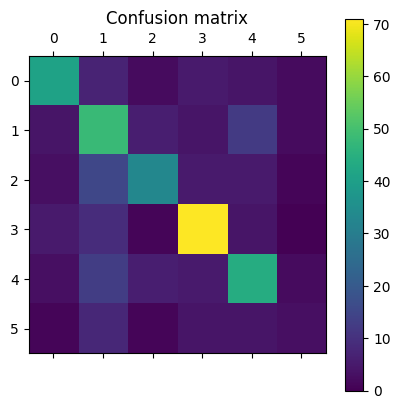

In [20]:
import pylab as pl

# To make it easy to understand the accuracy, print the confusion matrix
def showconfusionmatrix(cm):
    pl.matshow(cm)
    pl.title('Confusion matrix')
    pl.colorbar()
    pl.show()

cm = confusion_matrix(true_class, predictions)
showconfusionmatrix(cm)

<Axes: >

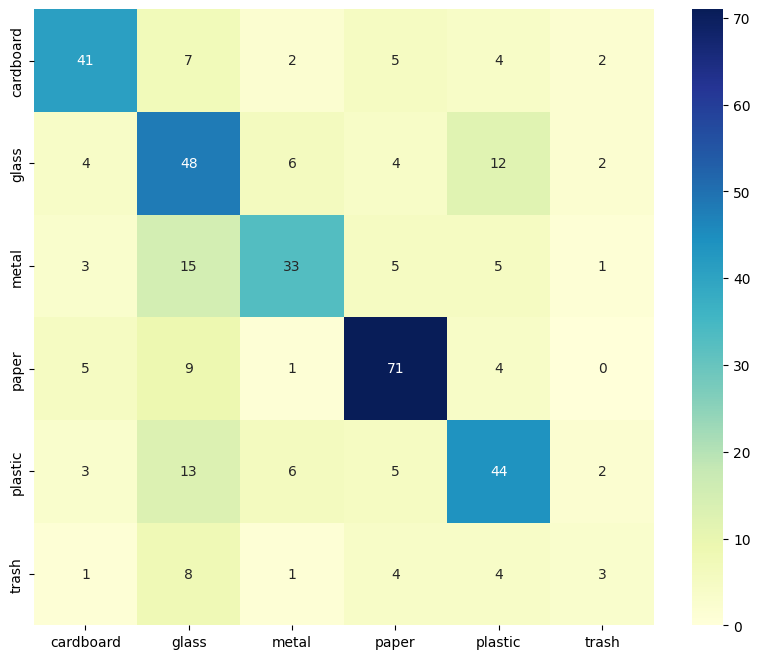

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_cm = pd.DataFrame(cm, waste_types, waste_types)

plt.figure(figsize = (10, 8))
sns.heatmap(df_cm, annot = True, fmt = "d", cmap = "YlGnBu")